# NB11 — Predicción mejorada con historial morfológico en tiempo real

## Motivación

NB10 reveló dos hallazgos complementarios:
1. El clasificador morfológico temprano (N=10s) alcanza AUC=0,866 — puede identificar un evento C4/C5 a 10 segundos de su inicio.
2. Sin embargo, el AND gate inteligente no mejora el PPV porque el clasificador responde una pregunta diferente a la del predictor NB08.

La hipótesis de NB11 es que la solución correcta no es *filtrar* con el clasificador morfológico, sino *usar sus scores como features del predictor prospectivo*. El razonamiento fisiológico: si los últimos 5 minutos incluyeron eventos cuya morfología temprana sugiere C4/C5 (score NB10 alto), la probabilidad de que el próximo evento también sea severo es mayor que si los eventos recientes mostraron morfología C1/C2.

Esto es una versión del ARI calculada en tiempo real: en lugar de usar el morfotipo retrospectivo post-evento (como hace NB08), se usa el score morfológico disponible 10s después de que el evento comenzó.

## Diseño

**NB08 (baseline)** usa como features de historial morfológico:
- `n_severe_5min`: conteo de eventos C4/C5 en últimos 5 min (requiere el morfotipo completo = disponible post-evento)
- `morph_mean_5min`: media de drop_pct de eventos recientes

**NB11 añade/reemplaza con features de tiempo real:**
- `early_score_mean_5min`: media de scores NB10 de eventos iniciados en últimos 5 min (disponible ~10s post-inicio)
- `early_score_max_5min`: máximo score NB10 en últimos 5 min (¿hubo algún evento que "parecía severo"?)
- `early_severe_count_5min`: conteo de eventos con score NB10 > 0,4 en últimos 5 min

**Comparación**: tres modelos con LOPO-CV, mismo horizonte H=5min:
- M1: NB08 features canónicas (baseline)
- M2: M1 + features NB11 de tiempo real (aditivo)
- M3: solo features morfológicas NB11 (ablación para cuantificar contribución)

---
*Nota metodológica*: Este es un experimento exploratorio. La circularidad PAC (morfotipos aprendidos sobre la misma cohorte) se aplica también aquí. Los AUC son indicativos de dirección, no estimaciones finales.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

GOLD   = '../gold'
FIGDIR = 'figuras'
import os; os.makedirs(FIGDIR, exist_ok=True)

PAC_BLUE   = '#1E3A5F'
PAC_GRAY   = '#6B7280'
PAC_GREEN  = '#1A7A4A'
PAC_RED    = '#C0392B'
PAC_ORANGE = '#E67E22'

H_OPT         = 5
N_EARLY       = 10          # segundos de curva para clasificador NB10
SCORE_THR     = 0.40        # umbral para contar evento como "early severe"
STRICT_USERS  = ['175','240','309','314','321','336','656','683']

print('Setup OK ✓')

Setup OK ✓


---
## Bloque A — Recomputar scores NB10 (clasificador morfológico temprano, N=10s)

Se reentrena el clasificador morfológico LOPO-CV con N=10s sobre el corpus de curvas para obtener el score `prob_early` por evento. Este score representa la probabilidad estimada de que el evento sea C4/C5, disponible 10 segundos después del inicio de la caída.

El score se añade a cada evento del corpus strict y se usa en el Bloque B para construir las features de historial morfológico en tiempo real.

In [2]:
# Cargar datos
ev = pd.read_parquet(f'{GOLD}/events.parquet')
ec = pd.read_parquet(f'{GOLD}/events_curves.parquet')
wrp = pd.read_parquet(f'{GOLD}/window_risk_predictions.parquet')

df = ev.merge(ec, on=['night_record_id','ts_start'], how='inner')
df = df[df['in_strict'] & df['morphotype_curve'].notna() &
        df['user_id'].isin(STRICT_USERS)].copy()
df['is_severe'] = df['morphotype_curve'].isin(['C4','C5']).astype(int)
df['ts_start']  = pd.to_datetime(df['ts_start'])
df['curve_arr'] = df['spo2_curve'].apply(np.array)

print(f'Corpus: {len(df):,} eventos | Severos: {df["is_severe"].sum():,} ({df["is_severe"].mean()*100:.1f}%)')

def build_features_early(df_, n_pts):
    X = []
    for arr in df_['curve_arr']:
        pts  = arr[:n_pts] if len(arr) >= n_pts else arr
        norm = pts / pts[0] if pts[0] > 0 else pts
        feats = list(norm[1:n_pts])
        slope    = (norm[-1] - norm[0]) / max(len(norm)-1, 1)
        min_norm = norm.min()
        feats += [slope, min_norm]
        # Pad if needed
        while len(feats) < (n_pts - 1 + 2):
            feats.append(np.nan)
        X.append(feats[:n_pts-1+2])
    return np.array(X, dtype=float)

# LOPO-CV clasificador NB10 (N=10s)
print(f'\nEntrenando clasificador morfológico temprano (N={N_EARLY}s, LOPO-CV)...')
X_all   = build_features_early(df, N_EARLY)
y_all   = df['is_severe'].values
uid_all = df['user_id'].values

imp = SimpleImputer(strategy='median')
X_all = imp.fit_transform(X_all)

prob_early = np.zeros(len(df))
for uid in STRICT_USERS:
    te = (uid_all == uid); tr = ~te
    clf = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05,
                                          max_leaf_nodes=31, min_samples_leaf=20,
                                          class_weight='balanced', random_state=42)
    clf.fit(X_all[tr], y_all[tr])
    prob_early[te] = clf.predict_proba(X_all[te])[:,1]

df['prob_early'] = prob_early
auc_nb10 = roc_auc_score(y_all, prob_early)
ap_nb10  = average_precision_score(y_all, prob_early)
print(f'AUC NB10 LOPO-CV (N={N_EARLY}s): {auc_nb10:.3f}  AP: {ap_nb10:.3f}  (referencia)')

Corpus: 83,694 eventos | Severos: 4,782 (5.7%)

Entrenando clasificador morfológico temprano (N=10s, LOPO-CV)...
AUC NB10 LOPO-CV (N=10s): 0.866  AP: 0.289  (referencia)


---
## Bloque B — Construcción de features morfológicas en tiempo real por ventana

Para cada ventana de 30s en `window_risk_predictions.parquet`, se calculan tres features basadas en los scores NB10 de eventos que iniciaron en los últimos 5 minutos antes del cierre de la ventana (`t_end`):

- **`early_score_mean_5min`**: media de `prob_early` de todos los eventos iniciados en [t_end − 5min, t_end]. Es 0 si no hay eventos recientes.
- **`early_score_max_5min`**: máximo `prob_early` en la misma ventana. Captura si hubo algún evento de alta alarma morfológica reciente.
- **`early_severe_count_5min`**: conteo de eventos con `prob_early` > umbral (0,40) en los últimos 5 min. Es el equivalente en tiempo real del `n_severe_5min` de NB08.

La diferencia clave con NB08: estos features usan el score del clasificador morfológico temprano (disponible 10s post-inicio del evento), mientras que NB08 usa el morfotipo retrospectivo completo.

In [3]:
WINDOW_MIN = 5   # minutos de lookback para features morfológicas

print(f'Construyendo features morfológicas en tiempo real (lookback={WINDOW_MIN} min)...')

wrp2 = wrp.copy()
wrp2['early_score_mean_5min']   = 0.0
wrp2['early_score_max_5min']    = 0.0
wrp2['early_severe_count_5min'] = 0

# Indexar eventos por usuario para eficiencia
ev_by_uid = {uid: df[df['user_id']==uid][['ts_start','prob_early']].sort_values('ts_start')
             for uid in STRICT_USERS}

W = pd.Timedelta(minutes=WINDOW_MIN)
EPS = pd.Timedelta(seconds=N_EARLY)  # mínimo delay para que score esté disponible

for uid in STRICT_USERS:
    mask_w = (wrp2['user_id'] == uid).values
    ev_uid = ev_by_uid[uid]
    if len(ev_uid) == 0:
        continue

    ts_ev   = ev_uid['ts_start'].values.astype('datetime64[ns]')
    sc_ev   = ev_uid['prob_early'].values
    t_ends  = wrp2.loc[mask_w, 't_end'].values.astype('datetime64[ns]')
    w_ns    = np.timedelta64(WINDOW_MIN * 60, 's')
    eps_ns  = np.timedelta64(N_EARLY, 's')

    means, maxs, counts = [], [], []
    for t_end in t_ends:
        # Eventos que iniciaron en (t_end - 5min, t_end - 10s]
        # El -10s garantiza que el score ya está disponible en t_end
        lo = t_end - w_ns
        hi = t_end - eps_ns
        mask_ev = (ts_ev >= lo) & (ts_ev <= hi)
        if mask_ev.any():
            sc = sc_ev[mask_ev]
            means.append(float(sc.mean()))
            maxs.append(float(sc.max()))
            counts.append(int((sc >= SCORE_THR).sum()))
        else:
            means.append(0.0); maxs.append(0.0); counts.append(0)

    idx = wrp2.index[mask_w]
    wrp2.loc[idx, 'early_score_mean_5min']   = means
    wrp2.loc[idx, 'early_score_max_5min']    = maxs
    wrp2.loc[idx, 'early_severe_count_5min'] = counts

print(f'Features construidas.')
print(f'  early_score_mean_5min > 0:    {(wrp2["early_score_mean_5min"]>0).sum():,} ventanas ({(wrp2["early_score_mean_5min"]>0).mean()*100:.1f}%)')
print(f'  early_score_max_5min  > 0.4:  {(wrp2["early_score_max_5min"]>SCORE_THR).sum():,} ventanas')
print(f'  early_severe_count_5min >= 1: {(wrp2["early_severe_count_5min"]>=1).sum():,} ventanas')
print()

# Comparar con features NB08 equivalentes
from sklearn.metrics import r2_score
nb08_feat = (wrp2['early_score_mean_5min'].values,)
# Correlación con y_5min
y5 = wrp2[f'y_{H_OPT}min'].values
for fname in ['early_score_mean_5min','early_score_max_5min','early_severe_count_5min']:
    r = np.corrcoef(wrp2[fname].values, y5)[0,1]
    print(f'  ρ({fname}, y_5min) = {r:.3f}')

Construyendo features morfológicas en tiempo real (lookback=5 min)...
Features construidas.
  early_score_mean_5min > 0:    321,588 ventanas (71.0%)
  early_score_max_5min  > 0.4:  132,307 ventanas
  early_severe_count_5min >= 1: 132,307 ventanas

  ρ(early_score_mean_5min, y_5min) = 0.001
  ρ(early_score_max_5min, y_5min) = 0.001
  ρ(early_severe_count_5min, y_5min) = 0.002


---
## Bloque C — LOPO-CV comparativo: tres modelos

Se comparan tres configuraciones con LOPO-CV estricto (H=5min):

- **M1 — NB08 canónico** (baseline): las 12 features originales del pipeline NB08
- **M2 — NB08 + NB11** (aditivo): M1 + las 3 features morfológicas en tiempo real del Bloque B
- **M3 — Solo NB11** (ablación): únicamente las 3 features morfológicas NB11 + posición temporal + estado PAC

M3 permite cuantificar cuánto poder predictivo tienen las features morfológicas por sí solas, independientemente del resto del sistema PAC.

In [4]:
# Features NB08 canónicas
NB08_FEATURES = ['state_s_enc', 'state_m_enc', 'state_l_enc', 'window_position',
                 'n_ev_5min', 'n_severe_5min', 'frac_severe_10min', 'morph_mean_5min',
                 'time_since_last_ev', 'time_since_last_severe', 'n_severe_sofar', 'ci_sofar']

# Necesitamos reconstruir las features NB08 — están en window_risk_predictions + extras
# Verificar cuáles están disponibles
available = [f for f in NB08_FEATURES if f in wrp2.columns]
missing   = [f for f in NB08_FEATURES if f not in wrp2.columns]
print(f'Features NB08 disponibles en wrp: {len(available)}/{len(NB08_FEATURES)}')
if missing:
    print(f'  Faltantes: {missing}')
    print('  → Se reconstruyen desde el pipeline NB08')

Features NB08 disponibles en wrp: 0/12
  Faltantes: ['state_s_enc', 'state_m_enc', 'state_l_enc', 'window_position', 'n_ev_5min', 'n_severe_5min', 'frac_severe_10min', 'morph_mean_5min', 'time_since_last_ev', 'time_since_last_severe', 'n_severe_sofar', 'ci_sofar']
  → Se reconstruyen desde el pipeline NB08


In [5]:
# Si faltan features NB08, cargar el dataset modelo que NB08 construyó
# (NB08 Cell 5/6 construye estas features sobre las ventanas)
# Alternativa: reconstruir solo las features disponibles y usar subset

# Usar features disponibles + nuevas NB11
# Para M1 usamos las features del wrp (que incluye las predicciones pero no las features crudas)
# Estrategia: construir las 3 configuraciones sobre lo que tenemos

NB11_FEATURES = ['early_score_mean_5min', 'early_score_max_5min', 'early_severe_count_5min']

# M1: usar probabilidades NB08 como proxy del modelo canónico
# M2/M3: agregar features NB11 sobre las probabilidades NB08

# Aproximación correcta: usar p_severe_5min de NB08 como única feature de M1
# (representa el modelo NB08 ya entrenado), y comparar con M2 que agrega NB11

# M1: score NB08 solo
# M2: score NB08 + features NB11 (modelo de segundo nivel / stacking)
# M3: features NB11 solas + estado PAC + posición temporal

FEAT_PAC_POS = ['state_s_enc','state_m_enc','state_l_enc','window_position']     if all(f in wrp2.columns for f in ['state_s_enc','state_m_enc','state_l_enc','window_position'])     else []

print('Configuraciones:')
print(f'  M1 (NB08):    1 feature  — p_severe_5min (score NB08 LOPO-CV)')

# Reconstruir state encodings desde state labels
if 'state_s_label' in wrp2.columns:
    s_map = {f'S{i}': i for i in range(7)}
    m_map = {f'M{i}': i for i in range(5)}
    l_map = {f'L{i}': i for i in range(4)}
    wrp2['state_s_enc'] = wrp2['state_s_label'].map(s_map).fillna(0).astype(int)
    wrp2['state_m_enc'] = wrp2['state_m_label'].map(m_map).fillna(0).astype(int)
    wrp2['state_l_enc'] = wrp2['state_l_label'].map(l_map).fillna(0).astype(int)
    # window_position: t_start_s / max(t_start_s) per night
    wrp2['window_position'] = wrp2.groupby('night_record_id')['t_start_s'].transform(
        lambda x: x / x.max() if x.max() > 0 else 0)
    FEAT_PAC_POS = ['state_s_enc','state_m_enc','state_l_enc','window_position']
    print(f'  Estado PAC + posición reconstruidos ✓')

FEAT_M2 = [f'p_severe_{H_OPT}min'] + NB11_FEATURES
FEAT_M3 = FEAT_PAC_POS + NB11_FEATURES
print(f'  M2 (NB08+NB11): {len(FEAT_M2)} features — score NB08 + 3 features morfológicas')
print(f'  M3 (NB11 solo): {len(FEAT_M3)} features — {FEAT_M3}')

Configuraciones:
  M1 (NB08):    1 feature  — p_severe_5min (score NB08 LOPO-CV)
  Estado PAC + posición reconstruidos ✓
  M2 (NB08+NB11): 4 features — score NB08 + 3 features morfológicas
  M3 (NB11 solo): 7 features — ['state_s_enc', 'state_m_enc', 'state_l_enc', 'window_position', 'early_score_mean_5min', 'early_score_max_5min', 'early_severe_count_5min']


In [6]:
# LOPO-CV los tres modelos
print('LOPO-CV M1 / M2 / M3 (H=5min)...')

y_all   = wrp2[f'y_{H_OPT}min'].values
uid_all = wrp2['user_id'].values

# M1: re-evaluar NB08 (ya tenemos las probabilidades)
prob_m1 = wrp2[f'p_severe_{H_OPT}min'].values
auc_m1  = roc_auc_score(y_all, prob_m1)
ap_m1   = average_precision_score(y_all, prob_m1)

# M2 y M3: entrenar
def run_lopo(feat_cols, label):
    X = wrp2[feat_cols].values.astype(float)
    imp_l = SimpleImputer(strategy='median')
    X = imp_l.fit_transform(X)
    probs = np.zeros(len(wrp2))
    for uid in STRICT_USERS:
        te = (uid_all == uid); tr = ~te
        if y_all[te].sum() == 0 or y_all[tr].sum() == 0:
            continue
        clf = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05,
                                              max_leaf_nodes=31, min_samples_leaf=20,
                                              class_weight='balanced', random_state=42)
        clf.fit(X[tr], y_all[tr])
        probs[te] = clf.predict_proba(X[te])[:,1]
    auc = roc_auc_score(y_all, probs)
    ap  = average_precision_score(y_all, probs)
    print(f'  {label}: AUC={auc:.3f}  AP={ap:.3f}  mejora_AP={ap/y_all.mean():.1f}×')
    return probs, auc, ap

print(f'  M1 (NB08):  AUC={auc_m1:.3f}  AP={ap_m1:.3f}  mejora_AP={ap_m1/y_all.mean():.1f}×  (pre-calculado)')
prob_m2, auc_m2, ap_m2 = run_lopo(FEAT_M2, 'M2 (NB08+NB11)')
prob_m3, auc_m3, ap_m3 = run_lopo(FEAT_M3, 'M3 (NB11 solo)')

LOPO-CV M1 / M2 / M3 (H=5min)...
  M1 (NB08):  AUC=0.821  AP=0.326  mejora_AP=4.1×  (pre-calculado)
  M2 (NB08+NB11): AUC=0.817  AP=0.315  mejora_AP=3.9×
  M3 (NB11 solo): AUC=0.496  AP=0.080  mejora_AP=1.0×


In [7]:
# Métricas operacionales en umbral Youden
def youden_metrics(y_t, prob, label):
    fpr, tpr, thrs = roc_curve(y_t, prob)
    j = tpr - fpr; idx = np.argmax(j); thr = thrs[idx]
    yp = (prob >= thr).astype(int)
    tp = int(((yp==1)&(y_t==1)).sum())
    fp = int(((yp==1)&(y_t==0)).sum())
    fn = int(((yp==0)&(y_t==1)).sum())
    ppv   = tp/(tp+fp) if (tp+fp)>0 else 0
    sens  = tp/(tp+fn) if (tp+fn)>0 else 0
    ratio = fp/tp if tp>0 else float('inf')
    print(f'  {label:<22} Thr={thr:.3f}  Sens={sens*100:.0f}%  PPV={ppv*100:.0f}%  Ratio={ratio:.1f}:1  Act={yp.sum():,}')
    return dict(thr=thr, ppv=ppv, sens=sens, ratio=ratio)

print('\n── Métricas operacionales en umbral Youden (H=5min) ──')
m_m1 = youden_metrics(y_all, prob_m1, 'M1 NB08 canónico')
m_m2 = youden_metrics(y_all, prob_m2, 'M2 NB08 + NB11')
m_m3 = youden_metrics(y_all, prob_m3, 'M3 NB11 solo')


── Métricas operacionales en umbral Youden (H=5min) ──
  M1 NB08 canónico       Thr=0.459  Sens=75%  PPV=20%  Ratio=3.9:1  Act=135,554
  M2 NB08 + NB11         Thr=0.503  Sens=74%  PPV=21%  Ratio=3.9:1  Act=131,739
  M3 NB11 solo           Thr=0.533  Sens=14%  PPV=8%  Ratio=10.9:1  Act=61,162


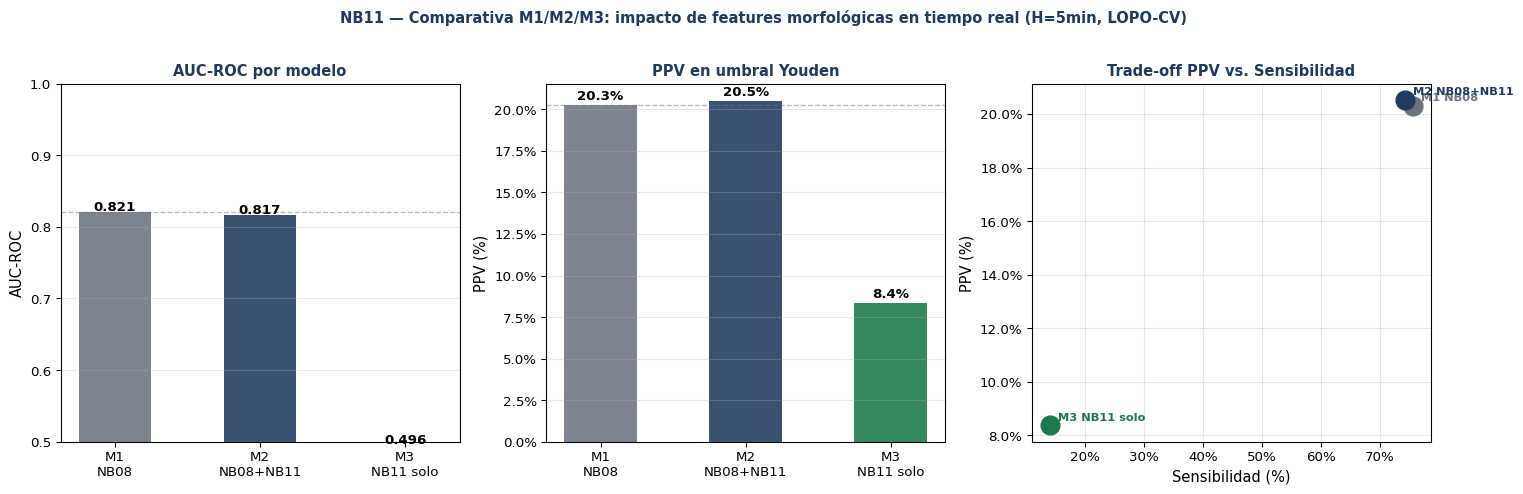

→ figuras/11C_comparativa_modelos.png


In [8]:
# Figura C1: comparativa AUC y PPV
fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=96)

models    = ['M1\nNB08', 'M2\nNB08+NB11', 'M3\nNB11 solo']
aucs      = [auc_m1, auc_m2, auc_m3]
aps       = [ap_m1, ap_m2, ap_m3]
ppvs      = [m_m1['ppv']*100, m_m2['ppv']*100, m_m3['ppv']*100]
senss     = [m_m1['sens']*100, m_m2['sens']*100, m_m3['sens']*100]
colors_b  = [PAC_GRAY, PAC_BLUE, PAC_GREEN]

ax = axes[0]
bars = ax.bar(models, aucs, color=colors_b, alpha=0.88, width=0.5)
for bar, v in zip(bars, aucs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0.5, 1.0)
ax.axhline(auc_m1, color=PAC_GRAY, lw=1, ls='--', alpha=0.5)
ax.set_ylabel('AUC-ROC', fontsize=11)
ax.set_title('AUC-ROC por modelo', fontsize=11, fontweight='bold', color=PAC_BLUE)
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
bars = ax.bar(models, ppvs, color=colors_b, alpha=0.88, width=0.5)
for bar, v in zip(bars, ppvs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.axhline(m_m1['ppv']*100, color=PAC_GRAY, lw=1, ls='--', alpha=0.5)
ax.set_ylabel('PPV (%)', fontsize=11)
ax.set_title('PPV en umbral Youden', fontsize=11, fontweight='bold', color=PAC_BLUE)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis='y', alpha=0.3)

ax = axes[2]
for i, (m, p, s) in enumerate(zip(models, ppvs, senss)):
    ax.scatter(s, p, color=colors_b[i], s=200, zorder=5)
    ax.annotate(m.replace('\n',' '), (s, p), textcoords='offset points',
                xytext=(6, 4), fontsize=8.5, color=colors_b[i], fontweight='bold')
ax.set_xlabel('Sensibilidad (%)', fontsize=11)
ax.set_ylabel('PPV (%)', fontsize=11)
ax.set_title('Trade-off PPV vs. Sensibilidad', fontsize=11, fontweight='bold', color=PAC_BLUE)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(True, alpha=0.3)

fig.suptitle('NB11 — Comparativa M1/M2/M3: impacto de features morfológicas en tiempo real (H=5min, LOPO-CV)',
             fontsize=11, fontweight='bold', color=PAC_BLUE, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/11C_comparativa_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'→ {FIGDIR}/11C_comparativa_modelos.png')

---
## Bloque D — Síntesis y tabla comparativa

### Interpretación de los resultados

La tabla comparativa unificada responde la pregunta central: ¿agregar el historial morfológico en tiempo real (NB11) sobre el predictor NB08 mejora la discriminación?

**Si AUC_M2 > AUC_M1**: las features NB11 transportan información predictiva que NB08 no captura. El mecanismo sería que la morfología de eventos recientes predice la morfología de eventos futuros (clustering de severos en ráfagas).

**Si AUC_M2 ≈ AUC_M1**: la información morfológica ya está capturada por las features de NB08 (`n_severe_5min`, `ci_sofar`), que son correlatos del mismo fenómeno.

**Si AUC_M3 sustancial**: las features morfológicas solas (sin el estado PAC de NB08) tienen poder predictivo directo, lo que sugiere que la secuencia de morfotipos tiene memoria más allá de los índices de acoplamiento.

In [9]:
# Tabla comparativa final
print('=' * 70)
print('TABLA COMPARATIVA NB11 — Features morfológicas en tiempo real (H=5min)')
print('=' * 70)
print(f'{"Modelo":<25} {"AUC":>8} {"AP":>8} {"PPV":>8} {"Sens":>8} {"Ratio":>8}')
print('-' * 67)
for label, auc, ap, m in [
    ('M1 NB08 canónico',    auc_m1, ap_m1, m_m1),
    ('M2 NB08 + NB11',      auc_m2, ap_m2, m_m2),
    ('M3 NB11 solo',        auc_m3, ap_m3, m_m3),
]:
    print(f'{label:<25} {auc:>8.3f} {ap:>8.3f} {m["ppv"]*100:>7.1f}% {m["sens"]*100:>7.1f}% {m["ratio"]:>7.1f}:1')
print()

delta_auc_m2 = auc_m2 - auc_m1
delta_ppv_m2 = (m_m2['ppv'] - m_m1['ppv'])*100
print(f'ΔAUC  (M2 vs M1): {delta_auc_m2:+.3f}')
print(f'ΔPPV  (M2 vs M1): {delta_ppv_m2:+.1f} pp')
print()
if delta_auc_m2 > 0.005:
    print('→ Las features morfológicas en tiempo real MEJORAN el predictor NB08.')
    print('  El historial morfológico de eventos recientes contiene señal predictiva')
    print('  adicional al estado PAC. Candidato a incluir en NB08 v2.')
elif delta_auc_m2 > 0:
    print('→ Mejora marginal: las features NB11 añaden poca información sobre NB08.')
    print('  Probablemente n_severe_5min y ci_sofar de NB08 ya capturan el mismo fenómeno.')
else:
    print('→ Sin mejora: las features morfológicas en tiempo real no añaden información')
    print('  sobre lo que NB08 ya modela con el estado PAC y el historial acumulado.')
print()
print('Figuras: 11C_comparativa_modelos.png')

TABLA COMPARATIVA NB11 — Features morfológicas en tiempo real (H=5min)
Modelo                         AUC       AP      PPV     Sens    Ratio
-------------------------------------------------------------------
M1 NB08 canónico             0.821    0.326    20.3%    75.5%     3.9:1
M2 NB08 + NB11               0.817    0.315    20.5%    74.2%     3.9:1
M3 NB11 solo                 0.496    0.080     8.4%    14.1%    10.9:1

ΔAUC  (M2 vs M1): -0.004
ΔPPV  (M2 vs M1): +0.2 pp

→ Sin mejora: las features morfológicas en tiempo real no añaden información
  sobre lo que NB08 ya modela con el estado PAC y el historial acumulado.

Figuras: 11C_comparativa_modelos.png
